# Matsubara → spectral function: Bethe lattice

Take the Bethe-lattice (semicircular-DOS) Green's function on a fermionic
Matsubara mesh, run [`minipole_matsubara`](../reference.html), and reconstruct
the real-frequency spectral function $A(\omega) = -\mathrm{Im}\,G(\omega +
i\eta) / \pi$. The Bethe lattice has a continuous spectrum, so the Minimal
Pole Method finds a discretized pole approximation; we'll see how well that
approximation reproduces the analytic semicircle.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from triqs.gfs import Gf, MeshImFreq, MeshReFreq

from minipole_interface import minipole_matsubara

## Set up the reference Green's function

Bethe lattice with half-bandwidth $D = 1$:
$$
\rho(\omega) = \frac{2}{\pi}\sqrt{1 - \omega^2}, \qquad |\omega| \le 1
$$
and the corresponding Hilbert transform
$$
G(z) = 2\left(z - \sqrt{z^2 - 1}\right)
$$
with the principal branch of the square root (chosen so $G(z) \sim 1/z$ at
large $|z|$).

In [2]:
def G_analytic(z):
    """Bethe-lattice Green's function, principal-branch sqrt."""
    z = np.asarray(z, dtype=complex)
    return 2.0 * (z - np.sqrt(z**2 - 1.0))


def rho_analytic(omega):
    omega = np.asarray(omega, dtype=float)
    out = np.zeros_like(omega)
    inside = np.abs(omega) < 1.0
    out[inside] = (2.0 / np.pi) * np.sqrt(1.0 - omega[inside] ** 2)
    return out

Sample $G$ on a fermionic Matsubara mesh.

In [3]:
beta = 100.0
n_iw = 200
mesh_iw = MeshImFreq(beta=beta, statistic="Fermion", n_iw=n_iw)

g = Gf(mesh=mesh_iw, target_shape=(1, 1))
for iw in mesh_iw:
    g[iw] = G_analytic(complex(iw))

## Run MPM

Letting `M` auto-select keeps the example clean; for a continuous spectrum
more poles give a better fit, with diminishing returns past ~20.

In [4]:
res = minipole_matsubara(g, M=20, compute_const=False)
print(f"recovered {len(res.pole_location)} poles")
print(f"upstream fit error: {res.fit_error}")

/mnt/home/wentzell/opt/myvenv9/lib/python3.12/site-packages/scipy/integrate/_quadpack_py.py:444: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  im_retval = quad(imfunc, a, b, args, full_output, epsabs,


recovered 17 poles
upstream fit error: 8.298084441804576e-13


## Plots

**(a)** The input on Matsubara, **(b)** the recovered pole locations in the
complex plane (note they cluster along the real axis, as expected for a
spectrum on $[-1, 1]$), and **(c)** the reconstructed spectral function
overlaid with the analytic semicircle.

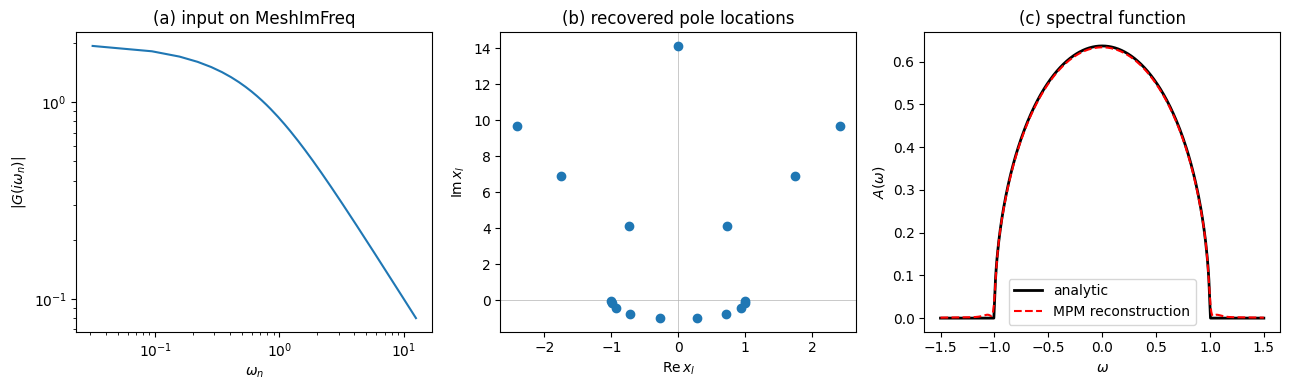

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# (a) input
iw_arr = np.array([complex(w) for w in mesh_iw])
positive = iw_arr.imag > 0
axes[0].plot(iw_arr[positive].imag, np.abs(g.data[positive, 0, 0]))
axes[0].set_xlabel(r"$\omega_n$")
axes[0].set_ylabel(r"$|G(i\omega_n)|$")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("(a) input on MeshImFreq")

# (b) recovered poles
axes[1].axhline(0.0, color="0.7", lw=0.5)
axes[1].axvline(0.0, color="0.7", lw=0.5)
axes[1].plot(res.pole_location.real, res.pole_location.imag, "o")
axes[1].set_xlabel(r"$\mathrm{Re}\,x_l$")
axes[1].set_ylabel(r"$\mathrm{Im}\,x_l$")
axes[1].set_title("(b) recovered pole locations")

# (c) reconstructed spectrum
mesh_re = MeshReFreq(-1.5, 1.5, 401)
g_re = res.to_gf_refreq(mesh_re, eta=5e-3)
omega = np.array([float(w) for w in mesh_re])
A_recon = -g_re.data[:, 0, 0].imag / np.pi
axes[2].plot(omega, rho_analytic(omega), "k-", lw=2, label="analytic")
axes[2].plot(omega, A_recon, "r--", label="MPM reconstruction")
axes[2].set_xlabel(r"$\omega$")
axes[2].set_ylabel(r"$A(\omega)$")
axes[2].legend()
axes[2].set_title("(c) spectral function")

plt.tight_layout()
plt.show()

## Sanity check

A correct reconstruction matches the analytic semicircle inside the support
and goes to zero outside (modulo the broadening tails set by `eta`). We
check the integrated weight is preserved.

In [6]:
domega = (omega[-1] - omega[0]) / (len(omega) - 1)
print(f"integrated reconstructed weight: {A_recon.sum() * domega:.4f} (should be ~1)")
print(f"integrated analytic weight:      {rho_analytic(omega).sum() * domega:.4f}")

integrated reconstructed weight: 0.9976 (should be ~1)
integrated analytic weight:      1.0001
